# Tâche 7

Déterminer la bande interdite,

Trouver la direction dans laquelle la dernière (première) bande de valence (conduction) présente le plus et le moins de dispersion (insérer une figure indiquant la dispersion par des flèches),

Calculer la masse effective au sommet (base) de la dernière (première) bande de valence (conduction) en supposant une dispersion parabolique.

In [1]:
import numpy as np
from mp_api.client import MPRester
from lmapr1492 import *
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt 
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.electronic_structure.core import Spin
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.electronic_structure.plotter import BSPlotter
from tabulate import tabulate
from IPython.display import Image

In [2]:
mp_key = "xaEW7gxeGjtHSTeJuWSz9Uf8JpzNlgtg"
mp_id = "mp-9382"

In [3]:
with MPRester(mp_key) as m:
    structure = m.get_structure_by_material_id(mp_id)
    el_bs = m.get_bandstructure_by_material_id(mp_id)
struct = SpacegroupAnalyzer(structure)
conv_structure = SpacegroupAnalyzer(structure).get_conventional_standard_structure()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

# 1) Structure de bande électronique du  SrZrN2 et zone de Brillouin

### Zone de Brillouin

La première zone de Brillouin est la cellule élémentaire du réseau réciproque, obtenue par construction de Wigner-Seitz dans l’espace des vecteurs d’onde $\vec{k}$.;De la même manière qu’une maille élémentaire permet de décrire entièrement un réseau cristallin direct, la zone de Brillouin suffit à représenter l’ensemble des propriétés du réseau réciproque.

L'importance de cette première zone de Brillouin provient de la description en ondes de Bloch des ondes dans un milieu périodique, dans lequel il est démontré que les solutions peuvent être complètement caractérisées par leur comportement dans cette zone.

Elle contient tous les vecteurs d’onde $\vec{k}$ distincts sur le plan physique (c’est-à-dire ne pouvant pas être reliés par un vecteur du réseau réciproque), ce qui signifie que toute la physique des électrons dans un cristal peut être analysée en se limitant à cette région.

Certains points de la zone de Brillouin, appelés points de haute symétrie (comme $ \Gamma $, $X $, $ L $, etc.), jouent un rôle clé : ce sont les positions où les symétries du réseau réciproque sont maximales, et ils servent souvent de repères pour tracer les chemins de calcul des bandes électroniques.

C’est pourquoi l’étude des bandes d’énergie électroniques $ \varepsilon(\vec{k}) $ est généralement restreinte à cette zone : elle renferme toutes les informations nécessaires sur les états électroniques d’un matériau périodique.


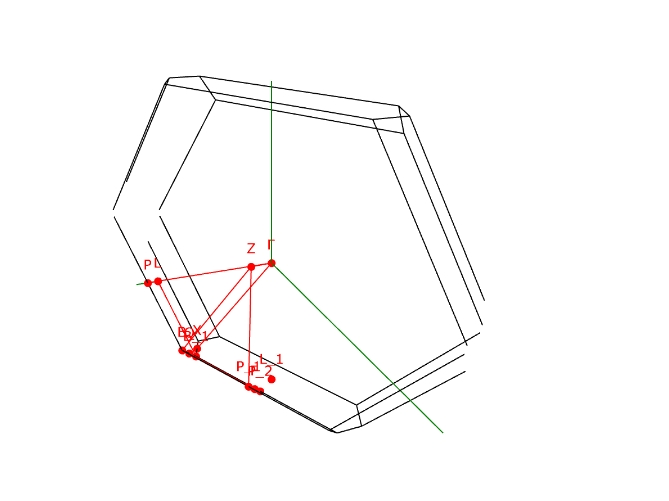

In [4]:
display(Image(filename="brillouin.png"))

Le diagramme des bandes électroniques représente la relation entre l’énergie des électrons dans un cristal et leur vecteur d’onde $ \vec{k} $, tracée le long de chemins à haute symétrie dans la zone de Brillouin, qui est une représentation de l'espace réciproque du cristal.

Il permet de visualiser :

- Les bandes de valence (niveaux d'énergie occupés)
- Les bandes de conduction (niveaux accessibles par excitation)
- La bande interdite (ou gap énergétique), entre valence et conduction
- La nature du gap (direct ou indirect)
- Les propriétés de conduction du matériau (conducteur, semi-conducteur ou isolant)

### Axes du diagramme :

- Axe horizontal : vecteur d’onde $ \vec{k} $, le long de chemins de haute symétrie dans la zone de Brillouin (points Γ, X, L, K, etc.)
- Axe vertical : énergie $ E-Ef $ représente l'énergie des électrons centrée autour de l'énergie de Fermi, en électron-volts (eV)





<Axes: xlabel='$\\mathrm{Wave\\ Vector}$', ylabel='$\\mathrm{E\\ -\\ E_f\\ (eV)}$'>

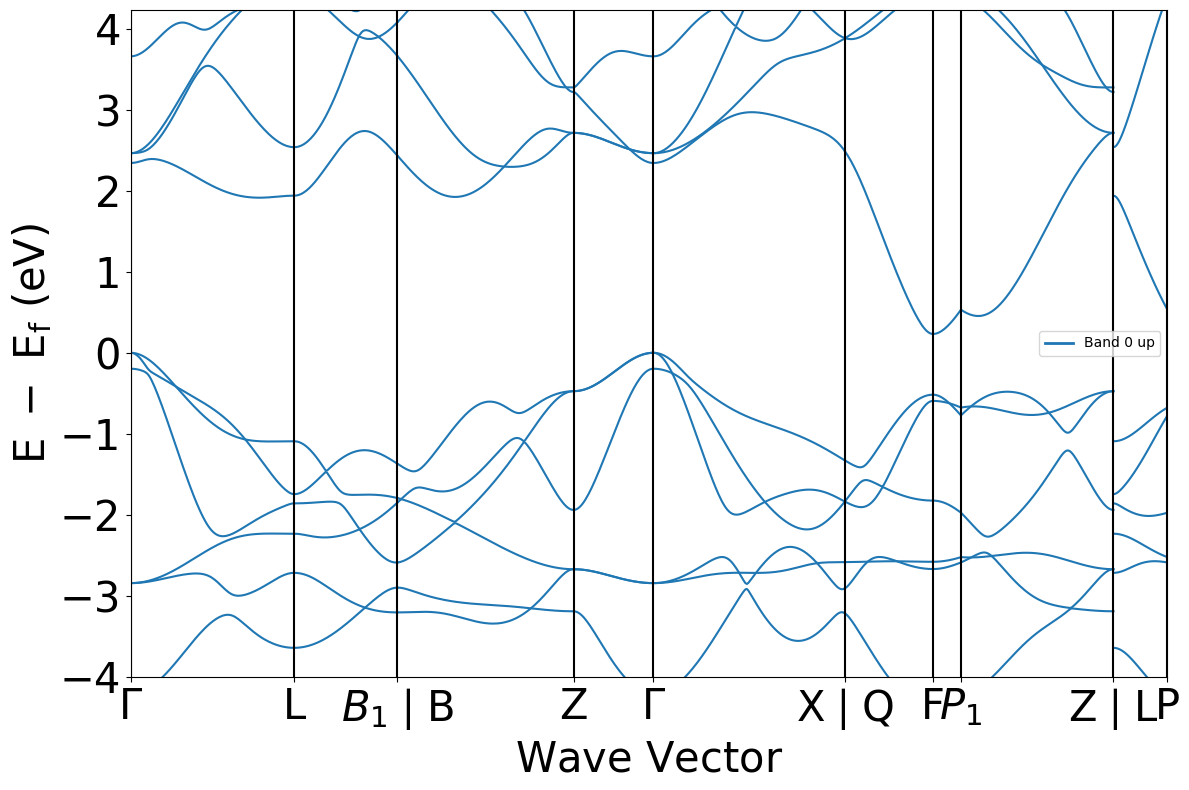

In [5]:
fig = BSPlotter(el_bs)
fig.get_plot()

# 2) Bande interdite

In [6]:
print(el_bs.get_band_gap())

{'direct': False, 'energy': 0.23249999999999993, 'transition': '\\Gamma-F'}


La bande interdite (ou gap de bande) correspond à l’intervalle énergétique séparant la bande de valence de la bande de conduction dans un matériau. Pour qu’un électron puisse passer de la bande de valence à la bande de conduction (et ainsi contribuer à la conduction électrique), il doit absorber une énergie au moins égale à celle de cette bande interdite.

Dans le cas étudié (SrZrN2), l’énergie de la bande interdite est Eg = 0.2325 eV. La transition électronique s’effectue entre le point Γ (sommet de la bande de valence) et le point F (base de la bande de conduction). Ce matériau est donc un semiconducteur, avec un gap inférieur à 1 eV.

La bande interdite est indirecte, le sommet de la bande de valence et la base de la bande de conduction ne se situent pas au même point dans l’espace réciproque. En d'autres termes, une bande interdite indirecte peut être décrite comme le phénomène dans lequel le maximum de la bande de valence ainsi que le minimum de la bande de conduction sont à différentes valeurs de k.

Dans les semi-conducteurs à bande interdite indirecte, la transition d'un électron de la bande de valence à la bande de conduction nécessite non seulement un apport d'énergie, mais aussi un changement de vecteur d'onde. Les photons, ayant un vecteur d'onde très faible, ne peuvent pas fournir ce changement. Par conséquent, un phonon doit intervenir pour compenser cette différence de vecteur d'onde.

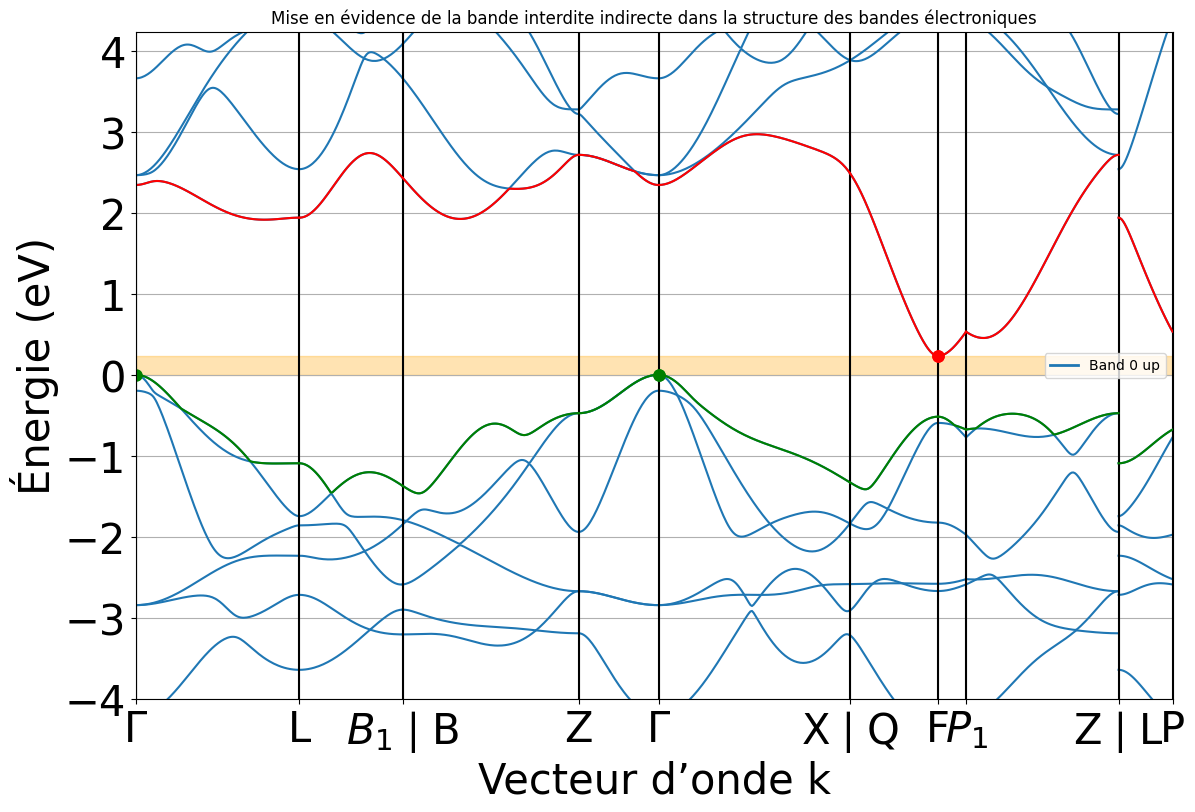


Dernière bande de valence :
Énergie du maximum de la bande de valence = 4.20 eV
Vecteur k en coordonnées cartésiennes = [0. 0. 0.]
Indices des bandes de valence : [14, 15]

Première bande de conduction :
Énergie minimum de la bande de conduction = 4.43 eV
Vecteur k en coordonnées cartésiennes = [ 0.52148528  0.         -0.99597691]
Indices des bandes de conduction : [16]


In [7]:
# 1) Extraction des données de la structure de bandes

bsplot = BSPlotter(el_bs)
bsdata = bsplot.bs_plot_data()

distance = bsdata.get('ticks').get('distance')
distances = bsdata.get('distances')
energy = bsdata.get('energy')

# 2) Indices des bandes extrêmes

vbm_band_index = el_bs.get_vbm()['band_index'][Spin.up][-1] 
cbm_band_index = el_bs.get_cbm()['band_index'][Spin.up][0]   

# 3) Affichage de la structure de bandes standard 

BSPlotter(el_bs).get_plot()

# 4) Tracé des bandes de valence (vert) et conduction (rouge) 

for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_band_index], color='green') 
    plt.plot(distances[i], energy['1'][i][cbm_band_index], color='red') 

# 5) Points VBM (verts) et CBM (rouges) 

cbm_coord = bsdata.get('cbm')
for (x, y) in cbm_coord:
    plt.plot(x, y, 'or', markersize=8)  # 'or' = red circle

vbm_coord = bsdata.get('vbm')
for (x, y) in vbm_coord:
    plt.plot(x, y, 'og', markersize=8)  # 'og' = green circle

# 6) Mise en évidence du gap énergétique 

plt.title("Mise en évidence de la bande interdite indirecte dans la structure des bandes électroniques")
plt.fill_between(
    np.linspace(distance[0], distance[-1], 500), 
    0, 
    el_bs.get_band_gap()['energy'], 
    color="orange",
    alpha=0.3
)

plt.xlabel("Vecteur d’onde k")
plt.ylabel("Énergie (eV)")
plt.grid(True)
plt.show()

# 7) Informations numériques sur le VBM et le CBM 

vbm = el_bs.get_vbm()
cbm = el_bs.get_cbm()

indices_vbm = list(vbm["band_index"].get(Spin.up, []))  
indices_cbm = list(cbm["band_index"].get(Spin.up, []))  

kpoint_vbm = vbm["kpoint"].cart_coords
kpoint_cbm = cbm["kpoint"].cart_coords

# 8)  Affichage des résultats 

print("\nDernière bande de valence :")
print("Énergie du maximum de la bande de valence = {:.2f} eV".format(vbm["energy"]))
print("Vecteur k en coordonnées cartésiennes =", kpoint_vbm)
print("Indices des bandes de valence :", indices_vbm)

print("\nPremière bande de conduction :")
print("Énergie minimum de la bande de conduction = {:.2f} eV".format(cbm["energy"]))
print("Vecteur k en coordonnées cartésiennes =", kpoint_cbm)
print("Indices des bandes de conduction :", indices_cbm)


# 3) Dispersion

La dispersion dans les bandes de conduction et de valence décrit comment l’énergie des électrons varie en fonction de leur vecteur d’onde k. Cette relation, notée E(k), influence directement la mobilité des électrons et les propriétés de transport électrique d’un matériau. La relation E(k) montre comment l'énergie de l'électron change lorsqu'il se déplace dans le matériau.  Un électron se déplace dans un matériau avec une vitesse de groupe proportionnelle à la pente de E(k). Plus cette pente est prononcée, plus l’électron est mobile. À l’inverse, une pente faible traduit une dispersion réduite et une mobilité plus limitée.

Dans un diagramme de bandes électroniques, une forte dispersion correspond à une bande inclinée, indiquant que les électrons peuvent se déplacer rapidement, une caractéristique favorable à la conductivité. En revanche, une bande plate reflète une faible dispersion, suggérant que les électrons sont plus localisés et moins aptes à se déplacer librement.

In [8]:
# 1) Récupère les distances des points k le long du chemin dans l'espace réciproque
x = np.unique(bsdata["ticks"]["distance"])  

# 2) Récupère les énergies de bande (structure électronique)
y = bsdata["energy"]

# 3) Nombre de segments entre points k
num_points = len(x) - 1 

# 4) Initialisation des tableaux pour les longueurs de segment et variations d'énergie
dx = np.zeros(num_points)          # Longueur de chaque segment k
dy_vbm = np.zeros(num_points)      # Variation d'énergie de la bande de valence pour chaque segment
dy_cbm = np.zeros(num_points)      # Variation d'énergie de la bande de conduction pour chaque segment
m_vbm = np.zeros(num_points)       # "Pente" (dispersion) pour la bande de valence
m_cbm = np.zeros(num_points)       # "Pente" (dispersion) pour la bande de conduction

# 5) Calcul des longueurs des segments entre les points k consécutifs
for i in range(num_points):
    dx[i] = x[i+1] - x[i]

# 6) Calcul de la variation d'énergie (dy) pour chaque segment, pour les bandes VBM et CBM
for i in range(num_points):
    dy_vbm[i] = y["1"][i][vbm_band_index][-1] - y["1"][i][vbm_band_index][0]  # VBM
    dy_cbm[i] = y["1"][i][cbm_band_index][-1] - y["1"][i][cbm_band_index][0]  # CBM

# 7) Calcul des dispersions (pentes) m = dy/dx pour chaque segment
for i in range(num_points):
    m_vbm[i] = dy_vbm[i] / dx[i]
    m_cbm[i] = dy_cbm[i] / dx[i]

# 8) Recherche des indices correspondant à la plus grande et la plus faible dispersion en valeur absolue
idx_max_vbm = np.argmax(abs(m_vbm))
idx_min_vbm = np.argmin(abs(m_vbm))
idx_max_cbm = np.argmax(abs(m_cbm))
idx_min_cbm = np.argmin(abs(m_cbm))

# 9) Affichage des résultats
print("En valeur absolue :")
print("La plus grande dispersion pour la bande de valence : {:.6f} (index {})".format(abs(m_vbm[idx_max_vbm]), idx_max_vbm))
print("La plus grande dispersion pour la bande de conduction : {:.6f} (index {})".format(abs(m_cbm[idx_max_cbm]), idx_max_cbm))
print("La plus faible dispersion pour la bande de valence : {:.6f} (index {})".format(abs(m_vbm[idx_min_vbm]), idx_min_vbm))
print("La plus faible dispersion pour la bande de conduction : {:.6f} (index {})".format(abs(m_cbm[idx_min_cbm]), idx_min_cbm))


En valeur absolue :
La plus grande dispersion pour la bande de valence : 1.392232 (index 5)
La plus grande dispersion pour la bande de conduction : 3.942881 (index 8)
La plus faible dispersion pour la bande de valence : 0.200407 (index 7)
La plus faible dispersion pour la bande de conduction : 0.115531 (index 4)


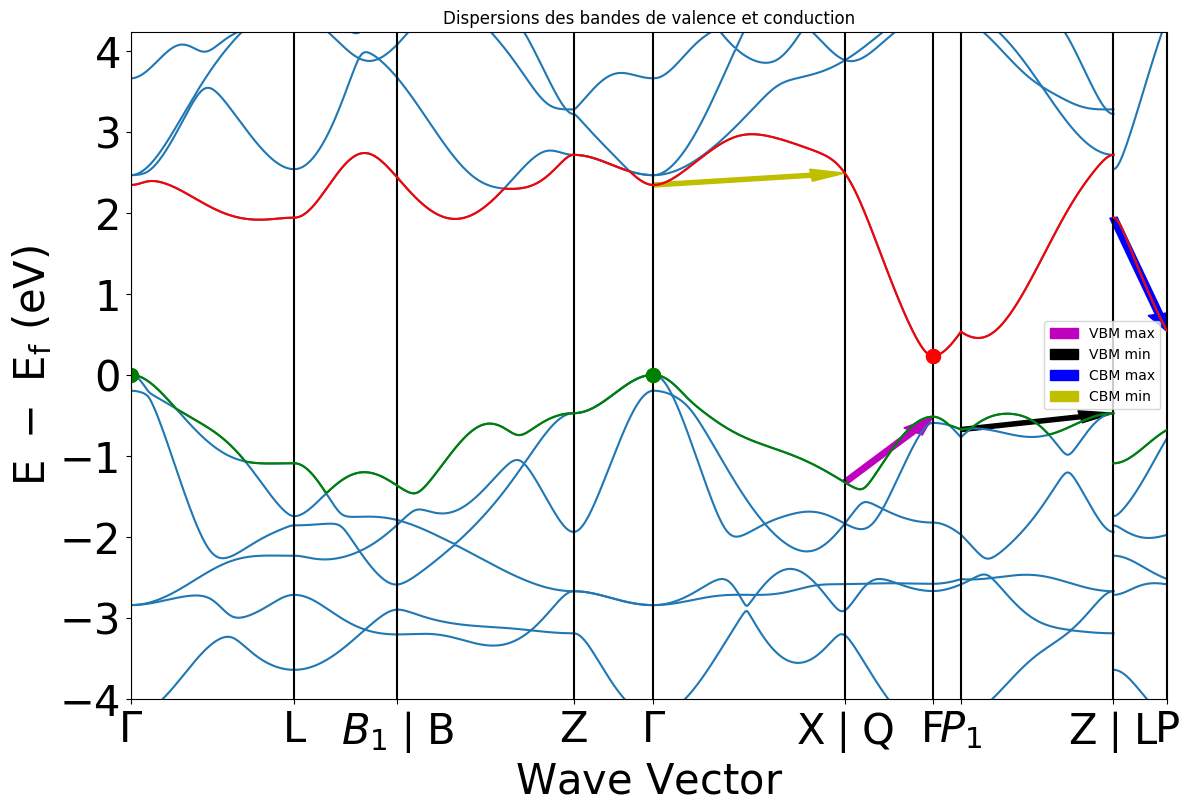

In [9]:
# 1) Affiche le diagramme de bandes
bsplot.get_plot()

# 2) Flèche pour la plus grande dispersion de la bande de valence

plt.arrow(x[idx_max_vbm], y["1"][idx_max_vbm][vbm_band_index][0], dx[idx_max_vbm], dy_vbm[idx_max_vbm], 
          color='m', width=0.05, head_width=0.15, length_includes_head=True, label="VBM max")

# 3) Flèche pour la plus faible dispersion de la bande de valence

plt.arrow(x[idx_min_vbm], y["1"][idx_min_vbm][vbm_band_index][0], dx[idx_min_vbm], dy_vbm[idx_min_vbm], 
          color='k', width=0.05, head_width=0.15, length_includes_head=True, label="VBM min") 

# 4) Flèche pour la plus grande dispersion de la bande de conduction

plt.arrow(x[idx_max_cbm], y["1"][idx_max_cbm][cbm_band_index][0], dx[idx_max_cbm], dy_cbm[idx_max_cbm], 
          color='b', width=0.05, head_width=0.15, length_includes_head=True, label="CBM max")

# 5) Flèche pour la plus faible dispersion de la bande de conduction

plt.arrow(x[idx_min_cbm], y["1"][idx_min_cbm][cbm_band_index][0], dx[idx_min_cbm], dy_cbm[idx_min_cbm], 
          color='y', width=0.05, head_width=0.15, length_includes_head=True, label="CBM min")

# 6) Mise en évidence des bandes

d = len(distances)
for i in range(d):
    plt.plot(distances[i], energy['1'][i][vbm_band_index], 'green') 
    plt.plot(distances[i], energy['1'][i][cbm_band_index], 'red')   

# 7) Marque des extremas

for (x, y) in bsdata.get("vbm"):
    plt.plot(x, y, 'og', markersize=10)  

for (x, y) in bsdata.get("cbm"):
    plt.plot(x, y, 'or', markersize=10) 

plt.title("Dispersions des bandes de valence et conduction")
plt.legend()
plt.show()

La dernière bande de valence présente donc le plus de dispersion dans la direction$X|Q–F$ et le moins de dispersion dans la direction $P₁-Z|L$.

La première bande de conduction présente donc le plus de dispersion dans la direction $Γ–X|Q$ et le moins de dispersion dans la direction $Z|L–P$.


# 4) Masse effective

Il est souvent intéressant de décrire les électrons commes des particules libres dont la masse effective varie plutôt que des particules de masse fixée évoluant dans un potentiel. Cette masse effective peut être positive ou négative, supérieur ou inférieure à la masse réelle de l'électron.

La masse effective est définie par le tenseur d'ordre 2 des dérivées secondes de l'énergie E par rapport au vecteur d'onde k : 

$ m^*_{ij} = \left( \frac{\partial^2 E}{\partial k_i \partial k_j} \right)^{-1}$

La courbure des bandes d’énergie fournit une indication directe de la capacité des électrons à accélérer sous l’effet d’un champ électrique. Cette propriété est caractérisée par la masse effective, qui permet de décrire le comportement dynamique des électrons comme s’ils étaient des particules libres, mais avec une masse modifiée par l’environnement cristallin. Lorsqu’une bande est plate, cela signifie que l’électron est peu sensible aux variations de son vecteur d’onde : sa masse effective est alors grande, et il se comporte comme une particule lourde et peu mobile. À l’inverse, une bande fortement dispersée (ou pentue) correspond à un électron léger, avec une faible masse effective, ce qui indique une grande mobilité dans le matériau.

Nous nous intéressons ici à la masse effective au sommet de la dernière bande de valence et au bas de la première bande de conduction. Afin de simplifier le calcul, nous supposons une dispersion parabolique, ce qui permet de modéliser la relation entre l’énergie et le vecteur d’onde sous la forme d’une parabole. L'équation de la parabole est donnée par : 

\begin{equation*}
y = a k^2 + b k + c
\end{equation*}




In [10]:
# Variables et changement d’unités

hbar2 = ((6.62607004e-34) / (2 * np.pi))**2  # ℏ²
electronvolt = 1.602176634e-19               # 1 eV en joules
angstrom = 1e-10                             # 1 Å en mètres


Résultats de l'ajustement quadratique autour du VBM :

Parabole d'approximation : y(k) = -5.867e+00·k² + 4.058e+01·k + -7.016e+01
Dérivée seconde           : -1.173e+01 eV·Å²
Masse effective du trou   : 5.916e-31 kg
Masse relative            : 0.649 m_e


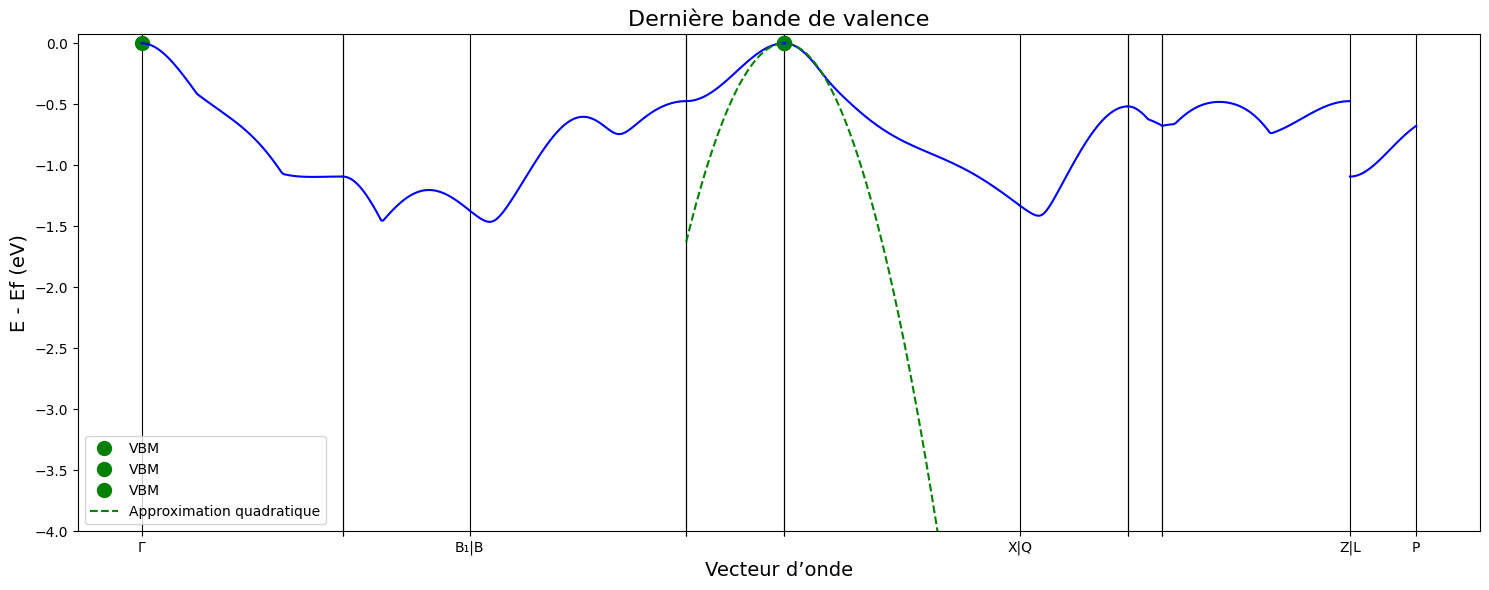

In [20]:
# 1) Création de la figure et des axes pour le tracé

fig, ax = plt.subplots(figsize=(15, 6))

# 2) Tracé des lignes verticales aux positions des points de discontinuité des segments k 

for d in distance:
    ax.axvline(d, color="black", linewidth=0.8)
    
# 3) Marquage du maximun et tracé de la dernière bande de valence

for x, y in vbm_coord:
    ax.plot(x, y, 'og', markersize=10, label='VBM')

for i in range(len(distances)):
    ax.plot(distances[i], energy.get('1')[i][vbm_band_index], 'b')
    
# 4) Configuration de la figure

ax.set_xticks(distance)
ax.set_xticklabels(['\u0393', 'L', '', 'B\u2081|B', 'Z', '', '\u0393', '', 'X|Q', 'F', '', 'P\u2081', '', 'Z|L', 'P'])
ax.set_xlabel('Vecteur d’onde', fontsize=14)
ax.set_ylabel('E - Ef (eV)', fontsize=14)
ax.set_title('Dernière bande de valence', fontsize=16)
ax.set_ylim(-4, None)

# 5) Sélection de 3 points autour du VBM pour ajustement quadratique

k_points = np.zeros(3)
energies = np.zeros(3)
k_points[1], energies[1] = vbm_coord[1]

# Points à gauche et à droite du VBM (pour interpolation quadratique)
k_points[0], energies[0] = distances[3][-2], energy.get('1')[3][vbm_band_index][-2]
k_points[2], energies[2] = distances[4][2], energy.get('1')[4][vbm_band_index][2]

#Ajustement quadratique : y = a·k² + b·k + c
coeffs = np.polyfit(k_points, energies, 2)
m_e = 9.10938356e-31  # kg
m_eff = hbar2 / (2 * abs(coeffs[0]) * electronvolt * angstrom**2)
m_eff_ratio = m_eff / m_e

# 6) Affichage des résultats

print("\nRésultats de l'ajustement quadratique autour du VBM :\n")
print(f"Parabole d'approximation : y(k) = {coeffs[0]:.3e}·k² + {coeffs[1]:.3e}·k + {coeffs[2]:.3e}")
print(f"Dérivée seconde           : {2 * coeffs[0]:.3e} eV·Å²")
print(f"Masse effective du trou   : {m_eff:.3e} kg")
print(f"Masse relative            : {m_eff_ratio:.3f} m_e")

x_fit = np.linspace(distances[3][0], distances[4][-1], 1000)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'g--', label='Approximation quadratique')

ax.legend()
plt.tight_layout()
plt.show()




Pour estimer la masse effective des trous dans la bande de valence, nous avons ajusté une parabole d’approximation autour du maximum de la bande de valence (VBM). Cette méthode repose sur le fait qu’à proximité d’un extremum, la relation entre l’énergie  E  et le vecteur d’onde k peut être approximée par une fonction quadratique :

$E(k) \approx a k^2 + b k + c$

L’ajustement numérique donne la parabole suivante :

$y(k) = -5{,}867 \times 10^0 \cdot k^2 + 4{,}058 \times 10^1 \cdot k - 7{,}016 \times 10^1$

À partir de la dérivée seconde de cette parabole, nous obtenons une valeur de :

$\frac{d^2E}{dk^2} = -1{,}173 \times 10^1 \ \text{eV·A²}$

En utilisant la relation :
$m^* = \frac{\hbar^2}{\frac{d^2E}{dk^2}}$

nous calculons une masse effective des trous de :
$m^* = 5{,}916 \times 10^{-31} \ \text{kg}$

Cette valeur représente environ 65 % de la masse d’un électron libre $(\frac{m^*}{m_e}  \approx 0{,}649) $.  Elle reflète la courbure modérée de la bande de valence autour du VBM, et suggère une mobilité raisonnable des trous, typique des matériaux semi-conducteurs à bande peu aplatie.


Résultats de l'ajustement quadratique autour du CBM :

Parabole d'approximation : y(k) = 2.174e+01·k² + -2.309e+02·k + 6.131e+02
Dérivée seconde           : 4.349e+01 eV·Å²
Masse effective de l’électron : 1.596e-31 kg
Masse relative                : 0.175 m_e


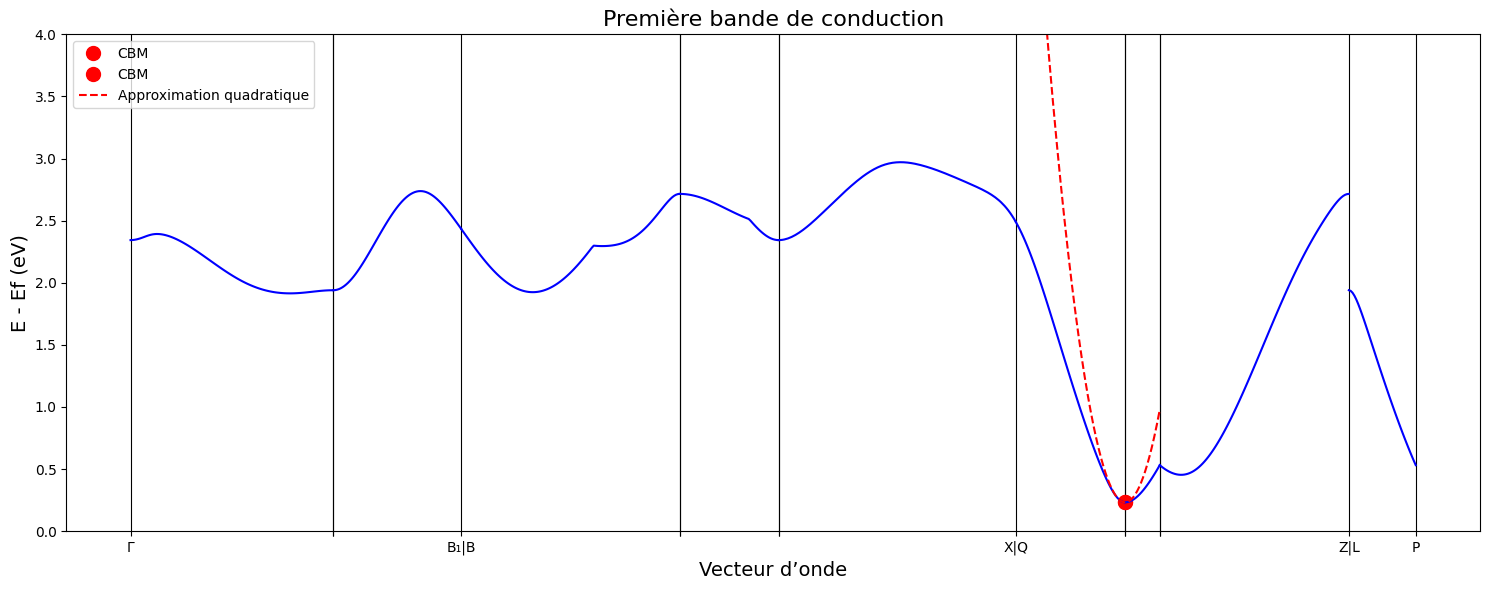

In [35]:
# 1) Création de la figure et des axes pour le tracé
fig, ax = plt.subplots(figsize=(15, 6))

# 2) Tracé des lignes verticales aux positions des points de discontinuité des segments k 
for d in distance:
    ax.axvline(d, color="black", linewidth=0.8)

# 3) Marquage du maximum et tracé de la première bande de conduction
for x, y in cbm_coord:
    ax.plot(x, y, 'or', markersize=10, label='CBM')

for i in range(len(distances)):
    ax.plot(distances[i], energy.get('1')[i][cbm_band_index], 'b')

# 4) Configuration de la figure
ax.set_xticks(distance)
ax.set_xticklabels(['\u0393', 'L', '', 'B\u2081|B', 'Z', '', '\u0393', '', 'X|Q', 'F', '', 'P\u2081', '', 'Z|L', 'P'])
ax.set_xlabel('Vecteur d’onde', fontsize=14)
ax.set_ylabel('E - Ef (eV)', fontsize=14)
ax.set_title('Première bande de conduction', fontsize=16)
ax.set_ylim(0, 4)

# 5) Sélection de 3 points autour du CBM pour ajustement quadratique
k_points_cbm = np.zeros(3)
energies_cbm = np.zeros(3)
k_points_cbm[1], energies_cbm[1] = cbm_coord[1]
k_points_cbm[0], energies_cbm[0] = distances[5][-2], energy.get('1')[5][cbm_band_index][-2]
k_points_cbm[2], energies_cbm[2] = (distances[6][1] + distances[6][2]) / 2, energy.get('1')[6][cbm_band_index][2]

# Ajustement quadratique : y = a·k² + b·k + c
coeffs_cbm = np.polyfit(k_points_cbm, energies_cbm, 2)



# Masse effective (conduction = courbure positive, donc coeffs_cbm[0] > 0 normalement)
m_e = 9.10938356e-31  # kg
m_eff_cbm = hbar2 / (2 * abs(coeffs_cbm[0]) * electronvolt * angstrom**2)
m_eff_ratio_cbm = m_eff_cbm / m_e

# 6) Affichage des résultats
print("\nRésultats de l'ajustement quadratique autour du CBM :\n")
print(f"Parabole d'approximation : y(k) = {coeffs_cbm[0]:.3e}·k² + {coeffs_cbm[1]:.3e}·k + {coeffs_cbm[2]:.3e}")
print(f"Dérivée seconde           : {2 * coeffs_cbm[0]:.3e} eV·Å²")
print(f"Masse effective de l’électron : {m_eff_cbm:.3e} kg")
print(f"Masse relative                : {m_eff_ratio_cbm:.3f} m_e")

# 7) Tracé de la parabole d’approximation
x_fit_cbm = np.linspace(distances[5][0], distances[6][-1], 1000)
ax.plot(x_fit_cbm, np.polyval(coeffs_cbm, x_fit_cbm), 'r--', label='Approximation quadratique')

ax.legend()
plt.tight_layout()
plt.show()


Pour estimer la masse effective des électrons dans la première bande de conduction, nous avons appliqué une approximation quadratique autour du minimum de la bande . En effet, à proximité d’un minimum d’énergie, la dispersion électronique peut être approchée par une parabole :

$E(k) \approx a k^2 + b k + c$

L’ajustement réalisé à partir de trois points proches du CBM donne l’équation suivante :

$y(k) = 2{,}174 \times 10^1 \cdot k^2 - 2{,}309 \times 10^2 \cdot k + 6{,}131 \times 10^2 $

La dérivée seconde de cette parabole est :
$\frac{d^2E}{dk^2} = 4{,}349 \times 10^1 \ \text{eV·A²}$

Ce qui permet de calculer la masse effective des électrons à partir de la formule :

$m^* = \frac{\hbar^2}{\frac{d^2E}{dk^2}}$

On obtient ainsi :

$m^* = 1{,}596 \times 10^{-31} \ \text{kg}$

Cette valeur représente environ 17,5 % de la masse d’un électron libre, soit $\frac{m^*}{m_e} \approx 0{,}175 $. Cela signifie que les électrons dans cette bande de conduction se déplacent avec une grande mobilité**, car une masse effective plus faible indique une bande très dispersive (forte courbure).


# 5) Informations complémentaires

En théorie des bandes, l’attention se porte principalement sur les électrons périphériques, c’est-à-dire ceux impliqués dans les liaisons chimiques et les propriétés électriques du matériau.Les électrons de cœur, quant à eux, sont fortement liés au noyau, chimiquement inactifs et ne participent pas à la conduction.

Les électrons périphériques occupent des bandes d’énergie permises, principalement réparties entre deux régions : la bande de valence et la bande de conduction. La position relative de ces deux bandes permet de classer un matériau comme conducteur, isolant, ou semi-conducteur.
 
### Conducteurs

Dans un conducteur tel que le cuivre, le 29ᵉ électron est situé dans la bande de valence, mais il est suffisamment libre pour accéder également à la bande de conduction. Cela signifie que les bandes de valence et de conduction se chevauchent, ce qui permet aux électrons de circuler librement sans apport d’énergie externe. Ce chevauchement est la caractéristique principale des matériaux conducteurs.

### Isolants

Dans un isolant comme le diamant (forme cristalline du carbone), tous les électrons sont impliqués dans des liaisons covalentes.
La bande de valence est entièrement remplie, tandis que la bande de conduction est vide. Ces deux bandes sont séparées par une large bande interdite (gap énergétique). Pour qu’un électron puisse passer de la bande de valence à la bande de conduction, il faut lui fournir une énergie importante, par exemple sous forme de chaleur ou via des photons très énergétiques (comme les ultraviolets ou les rayons X).

### Semi-conducteurs

Les semi-conducteurs, tels que le germanium ou le silicium, présentent une situation intermédiaire. La bande interdite existe toujours, mais elle est nettement plus étroite que dans un isolant. Un léger apport d’énergie (chauffage ou rayonnement) suffit à exciter certains électrons, qui peuvent alors passer dans la bande de conduction et ainsi permettre le passage du courant électrique.

### Niveau de Fermi

Le niveau de Fermi correspond au dernier niveau d’énergie occupé par un électron à température nulle. Dans un conducteur, il se situe dans la bande de conduction ou dans la zone de chevauchement avec la bande de valence. Dans un isolant ou un semi-conducteur, il est situé dans la bande interdite, entre la bande de valence et celle de conduction.

### Vecteur d'onde


Le vecteur d’onde $ \vec{k} $ décrit la périodicité spatiale de la fonction d’onde de l’électron dans un cristal. Il est lié à la solution des équations de Schrödinger dans un milieu périodique, comme un solide cristallin.

La fonction d’onde d’un électron dans un cristal s’écrit, selon le théorème de Bloch :

$$
\psi(\vec{r}) = e^{i \vec{k} \cdot \vec{r}} \, u_{k}(\vec{r})
$$

où :

- $ \psi(\vec{r}) $ : fonction d’onde totale de l’électron
- $ u_{k}(\vec{r}) $ : fonction périodique, ayant la même périodicité que le réseau cristallin
- $ \vec{k} $ : vecteur d’onde, aussi appelé vecteur de Bloc ou quasi-moment

Ce vecteur \$\vec{k} $ permet de décrire comment l’électron se propage dans un réseau périodique.